<a href="https://colab.research.google.com/github/jamshid719/pytorch_dive_deep/blob/main/01_pytorch_workflow_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [118]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(torch.__version__)

2.11.0+cpu


In [119]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


###Workflow: 1. data(pre and load) => 2. build model(or use pretrained model) => 3. training => 4. making predictions and evaluvating a model => 5. saving model => 6. putting it all together

## 1. Data (preparing and loading)

In [120]:
import sklearn
from sklearn.datasets import make_circles

In [121]:
# make 1000 samples
n_samples = 1000

#create circles
X, y = make_circles(n_samples, noise = 0.03, random_state=42)

len(X), len(y)

(1000, 1000)

In [122]:
import pandas as pd
circles = pd.DataFrame({ "X1": X[:, 0], "X2": X[:, 1], "label": y })
circles.head(7)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1


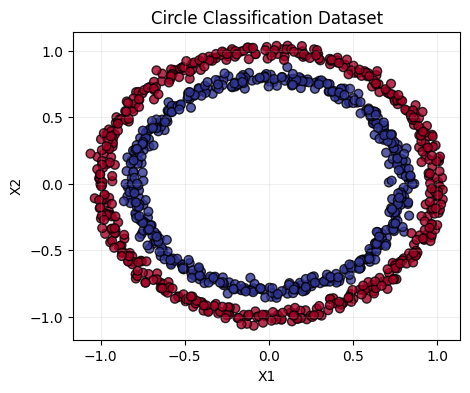

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))

plt.scatter(
    x=X[:, 0],
    y=X[:, 1],
    c=y,
    cmap=plt.cm.RdYlBu,
    s=40,
    alpha=0.8,
    edgecolors="black"
)

plt.title("Circle Classification Dataset")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(alpha=0.2)

plt.show()

In [124]:
#View the first example of features and labels
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")



Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


In [125]:
import torch
torch.__version__

'2.11.0+cpu'

In [126]:
# Turn data into tensors
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float()

X[:5], y[:5]



(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [127]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [128]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, #20% is for test data
    random_state=42
)

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

2. Building a model

Let's build a model to classify our blue and red dots.

To do so, we want to:

1. Setup device agnostic code so our code will run on an accelerator (GPU) if there is one
2. Construct a model (by subclassing nn.Module)
3. Define a loss function and optimizer
4. Create a training and test loop

In [129]:
# Import PyTorch and nn
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

device


'cpu'

In [130]:
# 1. Construct a model that subclasses nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()

        # 2. Create 2 nn.Linear layers capable of handling the shapes of our data
        self.layer_1 = nn.Linear(
            in_features=2,
            out_features=5
        )

        self.layer_2 = nn.Linear(
            in_features=5,
            out_features=1
        )

    # 3. Define a forward() method that outlines the forward pass
    def forward(self, x):
        return self.layer_2(self.layer_1(x))  # x -> layer_1 -> layer_2 -> output

# 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV0().to(device)

model_0
# model_0.state_dict()

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [131]:
# replicate this model by nn.Sequential() => kod qisqaroq buladi
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()

        # 2. Create 2 nn.Sequential()
        self.model = nn.Sequential(
               nn.Linear(2, 5),
               nn.Linear(5, 1)
        )


    # 3. Define a forward() method that outlines the forward pass
    def forward(self, x):
        return self.model(x) # x -> layer_1 -> layer_2 -> output

# 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV0().to(device)

model_0
model_0.state_dict()

OrderedDict([('model.0.weight',
              tensor([[-0.2932,  0.0423],
                      [-0.4069, -0.3680],
                      [ 0.5141,  0.3553],
                      [ 0.0051, -0.3914],
                      [-0.3968, -0.0823]])),
             ('model.0.bias',
              tensor([ 0.6386,  0.2638, -0.0273,  0.5481,  0.2861])),
             ('model.1.weight',
              tensor([[ 0.1125,  0.4464,  0.3971,  0.3980, -0.4291]])),
             ('model.1.bias', tensor([-0.2867]))])

In [132]:
# Make predictions
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))

print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 5 predictions:\n{untrained_preds[:5]}")
print(f"\nFirst 5 labels:\n{y_test[:5]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 5 predictions:
tensor([[-0.1682],
        [-0.1435],
        [-0.0826],
        [-0.1930],
        [ 0.1558]])

First 5 labels:
tensor([1., 0., 1., 0., 1.])


2.1 Setup loss function and optimizer

Which loss function or optimizer should you use?

Again... this is problem specific.

For example for regression you might want MAE or MSE
(mean absolute error or mean squared error).

For classification you might want binary cross entropy
or categorical cross entropy (cross entropy).

In [132]:
#Setup the loss function
loss_fn = nn.BCEWithLogitsLoss() #BCEWithLogitsLoss() = sigmoid activation function built-in

optimizer = torch.optim.SGD(params=model_0.parameters(), lr =0.1)

In [133]:
# Calculate accuracy => modelning nechta prediction’i to‘g‘ri chiqqanini foizda ko‘rsatadi.
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc